# Home Credit Default Risk
Predict how capable each applicant is of repaying a loan?

Kaggle: https://www.kaggle.com/competitions/home-credit-default-risk/data

Submissions are evaluated on ROC-AUC score

Data:
- application_{train|test}.csv - main table, one row represents one loan;
- bureau.csv - all client's previous credits provided by other financial institutions;
- bureau_balance.csv - monthly balances of previous credits;
- POS_CASH_balance.csv - monthly balance snapshots of previous *point of sales* and cash loans that the applicant had with Home Credit;
- credit_card_balance.csv - monthly balance snapshots of previous credit cards that the applicant has with Home Credit;
- previous_application.css - all previous applicants for Home Credit loans of clients who have loans in our sample;
- installments_payments.csv - repayment history for the previously distributed credits in Home Credit;
- HomeCredit_columns_description.csv - description for columns.

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import random
warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)

In [77]:
DATA_PATH = Path('./data')
df_train = pd.read_csv(DATA_PATH / 'application_train.csv')
df_test = pd.read_csv(DATA_PATH / 'application_test.csv')
bureau = pd.read_csv(DATA_PATH / 'bureau.csv')
pos = pd.read_csv(DATA_PATH / 'POS_CASH_balance.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
print(f'Bureau shape: {bureau.shape}')
print(f'POS_CASH shape: {pos.shape}')
print(f'\n Train columns: {df_train.columns.tolist()[:10]}...')

Train shape: (307511, 122)
Test shape: (48744, 121)
Bureau shape: (1716428, 17)
POS_CASH shape: (10001358, 8)

 Train columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...


In [78]:
df_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


![image.png](./img/home_credit.png)

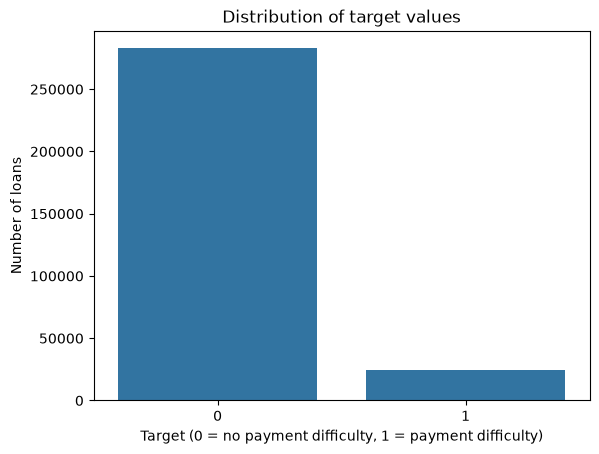

In [79]:
sns.countplot(data=df_train, x='TARGET')
plt.title('Distribution of target values')
plt.xlabel('Target (0 = no payment difficulty, 1 = payment difficulty)')
plt.ylabel('Number of loans')
plt.show()

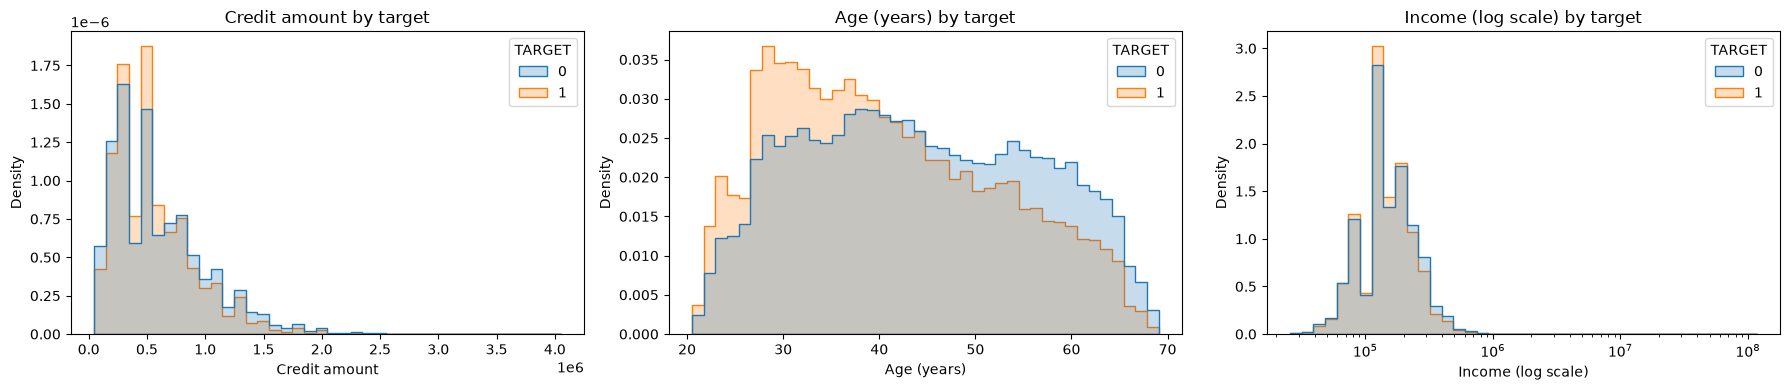

In [80]:
plot_df = df_train.assign(AGE_YEARS=-df_train['DAYS_BIRTH'] / 365.25)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, column, label in zip(
    axes,
    ['AMT_CREDIT', 'AGE_YEARS', 'AMT_INCOME_TOTAL'],
    ['Credit amount', 'Age (years)', 'Income (log scale)'],
):
    sns.histplot(
        data=plot_df, x=column, hue='TARGET', bins=40,
        stat='density', common_norm=False, element='step',
        log_scale=(column == 'AMT_INCOME_TOTAL'), ax=ax,
    )
    ax.set_title(f'{label} by target')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

`EXT_SOURCE_1-3` are normalized credit scores from external data sources.

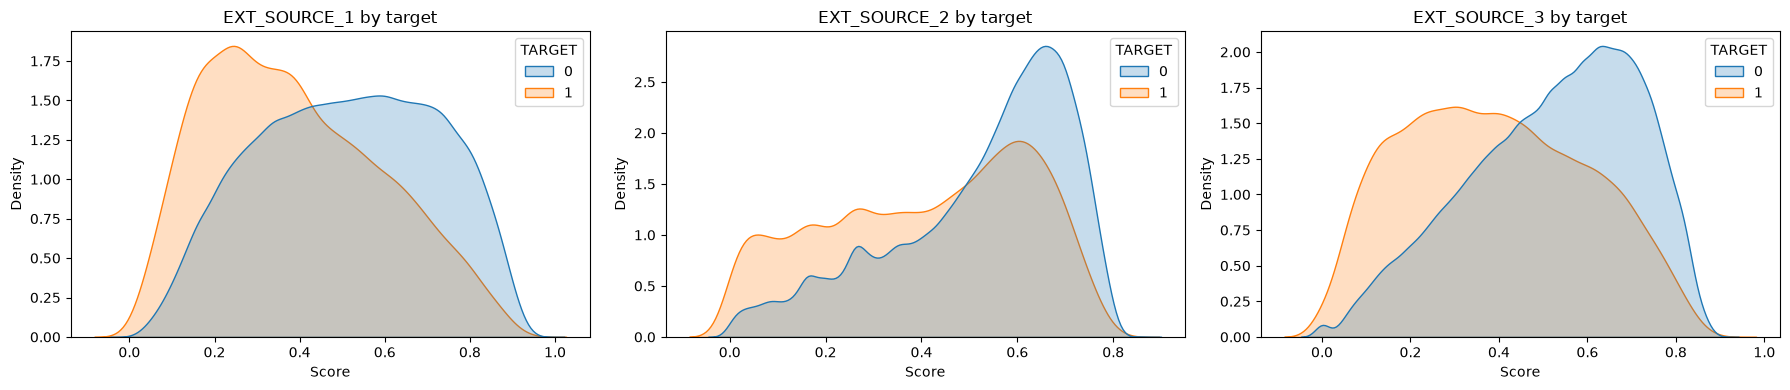

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=df_train, x=column, hue='TARGET', common_norm=False, fill=True, ax=ax)
    ax.set_title(f'{column} by target')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

## Credit bureau features
`bureau.csv` holds the client's earlier loans from other lenders, as reported to the credit bureau: amounts, debt, credit limits, and open and close dates.

Hypotheses:
- High credit card utilization raises default risk
- Taking many loans recently raises default risk
- A heavy debt load relative to income raises default risk
- Closing loans early lowers default risk
- A longer credit history lowers default risk
- Clients without bureau history default at a different rate

In [81]:
active = bureau['CREDIT_ACTIVE'].eq('Active')
card_limit = bureau['AMT_CREDIT_SUM_LIMIT'].where(
    bureau['CREDIT_TYPE'].eq('Credit card') & bureau['AMT_CREDIT_SUM_LIMIT'].gt(0)
)
bureau = bureau.assign(
    IS_ACTIVE=active,
    DAYS_SINCE_OPENED=-bureau['DAYS_CREDIT'],
    OPENED_LAST_YEAR=bureau['DAYS_CREDIT'].ge(-365),
    ACTIVE_DEBT=bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0).where(active, 0),
    ACTIVE_CREDIT=bureau['AMT_CREDIT_SUM'].where(active, 0),
    CARD_UTILIZATION=bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0) / card_limit,
    CLOSED_EARLY=bureau['DAYS_ENDDATE_FACT'].lt(bureau['DAYS_CREDIT_ENDDATE']),
)
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_CARD_UTILIZATION=('CARD_UTILIZATION', 'mean'),
    BUREAU_DAYS_SINCE_LAST_LOAN=('DAYS_SINCE_OPENED', 'min'),
    BUREAU_N_LOANS_LAST_YEAR=('OPENED_LAST_YEAR', 'sum'),
    BUREAU_N_ACTIVE=('IS_ACTIVE', 'sum'),
    BUREAU_ACTIVE_SHARE=('IS_ACTIVE', 'mean'),
    BUREAU_EARLY_CLOSE_SHARE=('CLOSED_EARLY', 'mean'),
    BUREAU_DAYS_SINCE_FIRST_LOAN=('DAYS_SINCE_OPENED', 'max'),
    ACTIVE_DEBT=('ACTIVE_DEBT', 'sum'),
    ACTIVE_CREDIT=('ACTIVE_CREDIT', 'sum'),
)

def add_bureau_features(frame):
    frame = frame.merge(bureau_agg, left_on='SK_ID_CURR', right_index=True, how='left')
    frame['HAS_BUREAU'] = frame['BUREAU_N_ACTIVE'].notna().astype(int)
    frame['BUREAU_DEBT_TO_INCOME'] = frame['ACTIVE_DEBT'] / frame['AMT_INCOME_TOTAL']
    frame['BUREAU_DEBT_STILL_OWED'] = frame['ACTIVE_DEBT'] / frame['ACTIVE_CREDIT'].replace(0, np.nan)
    return frame.drop(columns=['ACTIVE_DEBT', 'ACTIVE_CREDIT'])

df_train = add_bureau_features(df_train)
df_test = add_bureau_features(df_test)
bureau_features = [
    'HAS_BUREAU', 'BUREAU_CARD_UTILIZATION',
    'BUREAU_DAYS_SINCE_LAST_LOAN', 'BUREAU_N_LOANS_LAST_YEAR',
    'BUREAU_N_ACTIVE', 'BUREAU_ACTIVE_SHARE', 'BUREAU_DEBT_TO_INCOME', 'BUREAU_DEBT_STILL_OWED',
    'BUREAU_EARLY_CLOSE_SHARE', 'BUREAU_DAYS_SINCE_FIRST_LOAN',
]
print(f'Train clients with bureau history: {df_train["HAS_BUREAU"].mean():.1%}')
df_train.groupby('HAS_BUREAU')['TARGET'].mean().rename('default rate').to_frame()

Train clients with bureau history: 85.7%


,default rate
HAS_BUREAU,
0,0.101249
1,0.077301


### Bureau data overview
How many train clients have bureau history, and how many loans they hold.

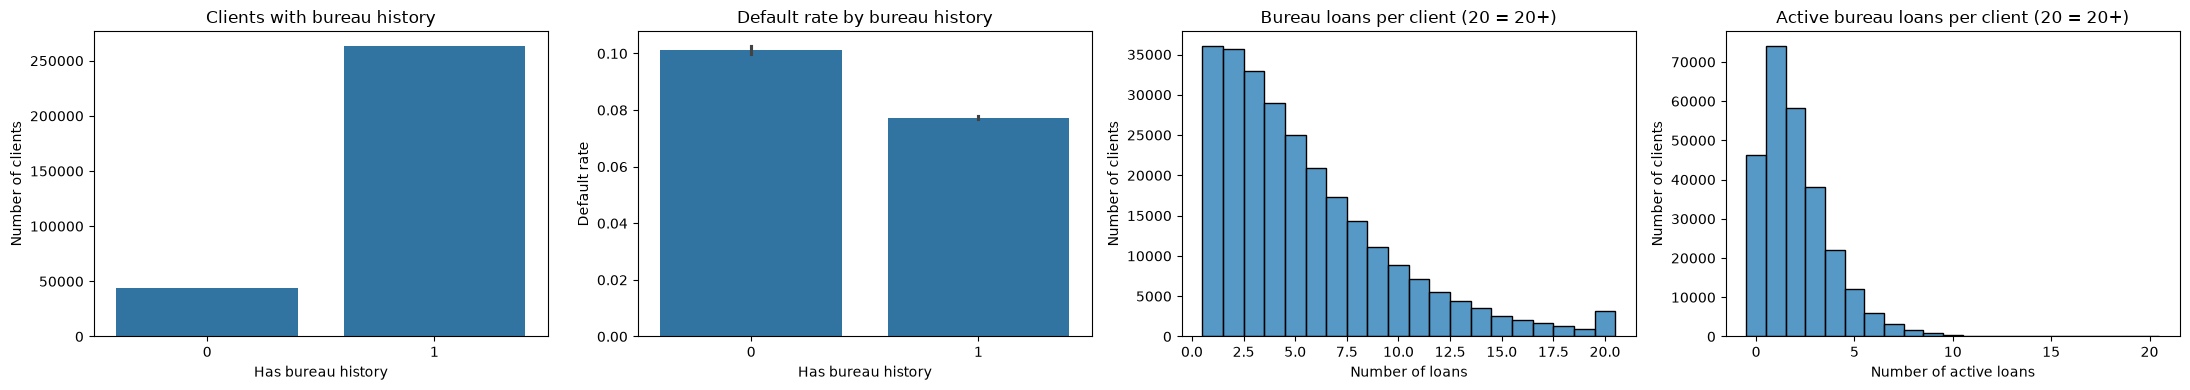

In [92]:
n_bureau_loans = df_train['SK_ID_CURR'].map(bureau['SK_ID_CURR'].value_counts())
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

sns.countplot(data=df_train, x='HAS_BUREAU', ax=axes[0])
axes[0].set_title('Clients with bureau history')
axes[0].set_xlabel('Has bureau history')
axes[0].set_ylabel('Number of clients')

sns.barplot(data=df_train, x='HAS_BUREAU', y='TARGET', errorbar='se', ax=axes[1])
axes[1].set_title('Default rate by bureau history')
axes[1].set_xlabel('Has bureau history')
axes[1].set_ylabel('Default rate')

sns.histplot(x=n_bureau_loans.clip(upper=20), discrete=True, ax=axes[2])
axes[2].set_title('Bureau loans per client (20 = 20+)')
axes[2].set_xlabel('Number of loans')
axes[2].set_ylabel('Number of clients')

sns.histplot(x=df_train['BUREAU_N_ACTIVE'].clip(upper=20), discrete=True, ax=axes[3])
axes[3].set_title('Active bureau loans per client (20 = 20+)')
axes[3].set_xlabel('Number of active loans')
axes[3].set_ylabel('Number of clients')

plt.tight_layout()
plt.show()

### Bureau hypotheses
Default rate across bins of each bureau feature, for clients with bureau history. Error bars show the standard error.

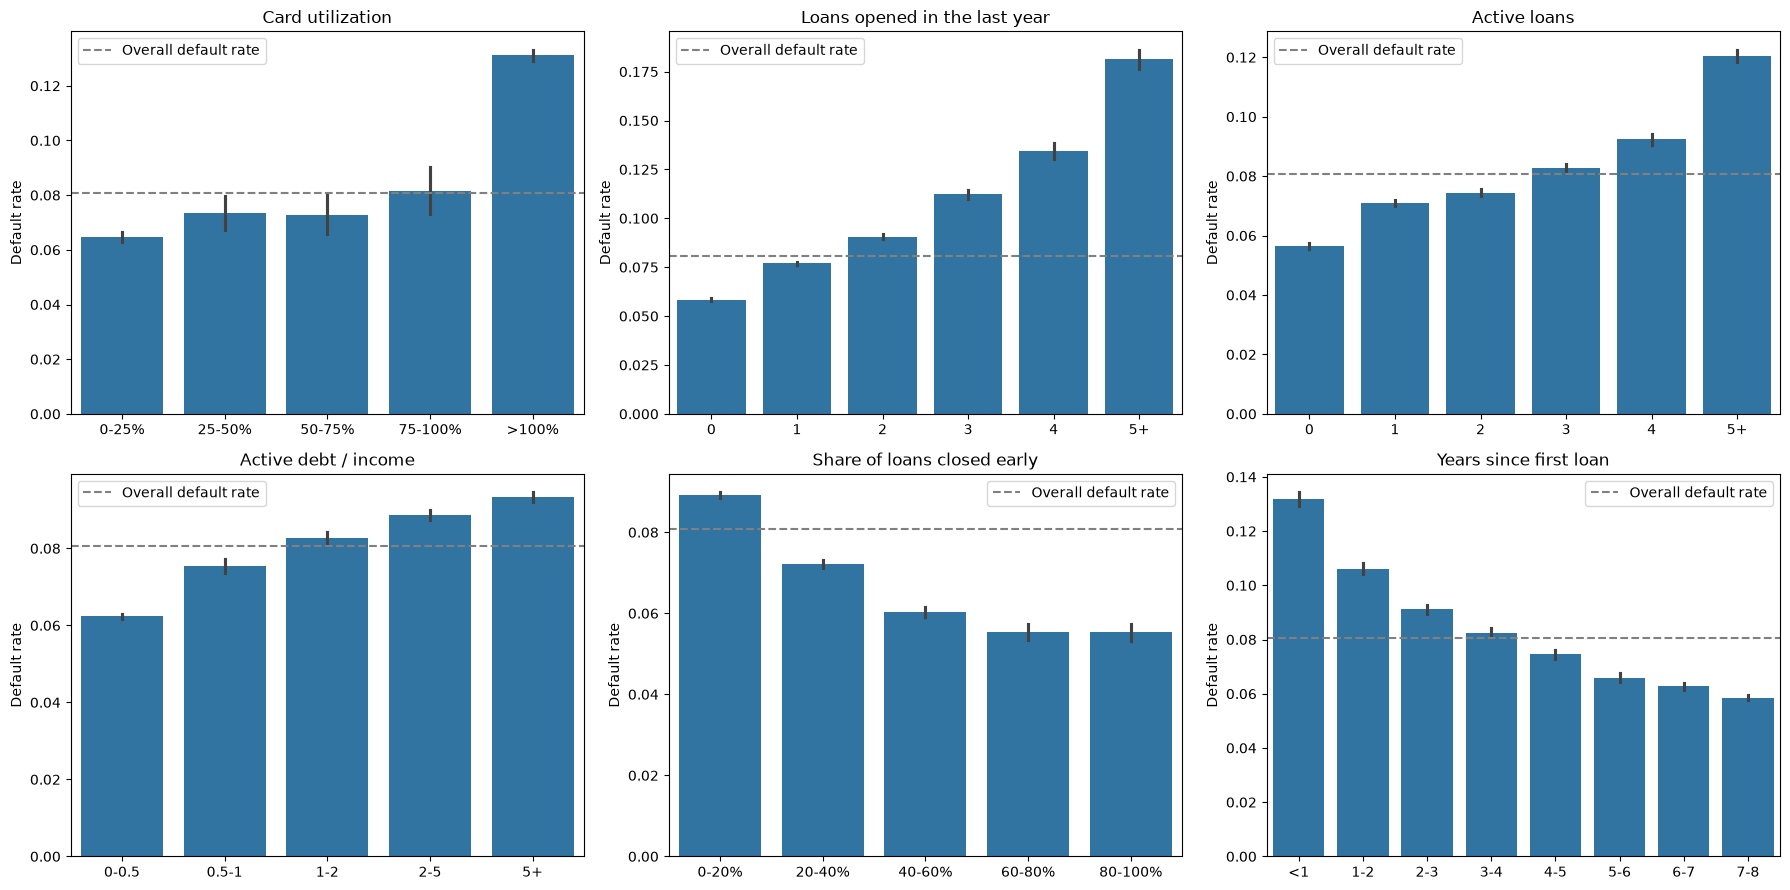

In [93]:
count_bins = ([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf], ['0', '1', '2', '3', '4', '5+'])
share_bins = ([0, 0.2, 0.4, 0.6, 0.8, 1], ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
panels = [
    ('BUREAU_CARD_UTILIZATION', [0, 0.25, 0.5, 0.75, 1, np.inf], ['0-25%', '25-50%', '50-75%', '75-100%', '>100%'], 'Card utilization'),
    ('BUREAU_N_LOANS_LAST_YEAR', *count_bins, 'Loans opened in the last year'),
    ('BUREAU_N_ACTIVE', *count_bins, 'Active loans'),
    ('BUREAU_DEBT_TO_INCOME', [0, 0.5, 1, 2, 5, np.inf], ['0-0.5', '0.5-1', '1-2', '2-5', '5+'], 'Active debt / income'),
    ('BUREAU_EARLY_CLOSE_SHARE', *share_bins, 'Share of loans closed early'),
    ('BUREAU_DAYS_SINCE_FIRST_LOAN', [0, 1, 2, 3, 4, 5, 6, 7, 8], ['<1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8'], 'Years since first loan'),
]
overall_rate = df_train['TARGET'].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (column, bins, labels, title) in zip(axes.flat, panels):
    values = df_train[column] / 365.25 if column.startswith('BUREAU_DAYS') else df_train[column]
    binned = pd.cut(values, bins=bins, labels=labels, include_lowest=True)
    sns.barplot(x=binned, y=df_train['TARGET'], errorbar='se', ax=ax)
    ax.axhline(overall_rate, color='grey', linestyle='--', label='Overall default rate')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Default rate')
    ax.legend()
plt.tight_layout()
plt.show()

## Home Credit POS and cash loan features
`POS_CASH_balance.csv` holds monthly snapshots of the client's earlier point-of-sale and cash loans at Home Credit: installments left and days past due.

Hypotheses:
- Recent late payments raise default risk more than old ones
- Frequent late payments raise default risk
- A longer history with more repaid loans lowers default risk
- A fresh loan taken right before applying raises default risk
- Clients without Home Credit history default at a different rate

In [82]:
# Late month: days past due, ignoring tiny debts.
pos = pos.assign(IS_LATE=pos['SK_DPD_DEF'].gt(0))
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_N_LOANS=('SK_ID_PREV', 'nunique'),  # number of earlier POS/cash loans
    POS_HIST_LEN=('MONTHS_BALANCE', lambda months: -months.min()),  # months of Home Credit history
    POS_DPD_SHARE=('IS_LATE', 'mean'),  # share of months with a late payment
)
# Months since the last late month (999 if never late).
pos_agg['POS_MONTHS_SINCE_DPD'] = -pos[pos['IS_LATE']].groupby('SK_ID_CURR')['MONTHS_BALANCE'].max()
# Share of installments left on active loans; high means a fresh loan.
last_month = pos.sort_values('MONTHS_BALANCE').groupby('SK_ID_PREV').tail(1)
active_last = last_month[last_month['NAME_CONTRACT_STATUS'].eq('Active') & last_month['CNT_INSTALMENT'].gt(0)]
pos_agg['POS_PROGRESS_LEFT'] = (
    (active_last['CNT_INSTALMENT_FUTURE'] / active_last['CNT_INSTALMENT'])
    .groupby(active_last['SK_ID_CURR']).mean()
)

def add_pos_features(frame):
    frame = frame.merge(pos_agg, left_on='SK_ID_CURR', right_index=True, how='left')
    # 1 if the client has earlier Home Credit POS/cash loans.
    frame['HAS_POS'] = frame['POS_N_LOANS'].notna().astype(int)
    frame['POS_MONTHS_SINCE_DPD'] = frame['POS_MONTHS_SINCE_DPD'].fillna(999)
    return frame

df_train = add_pos_features(df_train)
df_test = add_pos_features(df_test)
pos_features = [
    'HAS_POS', 'POS_N_LOANS', 'POS_HIST_LEN', 'POS_DPD_SHARE',
    'POS_MONTHS_SINCE_DPD', 'POS_PROGRESS_LEFT',
]
print(f'Train clients with POS history: {df_train["HAS_POS"].mean():.1%}')
df_train.groupby('HAS_POS')['TARGET'].mean().rename('default rate').to_frame()

Train clients with POS history: 94.1%


,default rate
HAS_POS,
0,0.066641
1,0.081608


### POS/cash data overview
How many train clients have Home Credit POS/cash history, and how long it is.

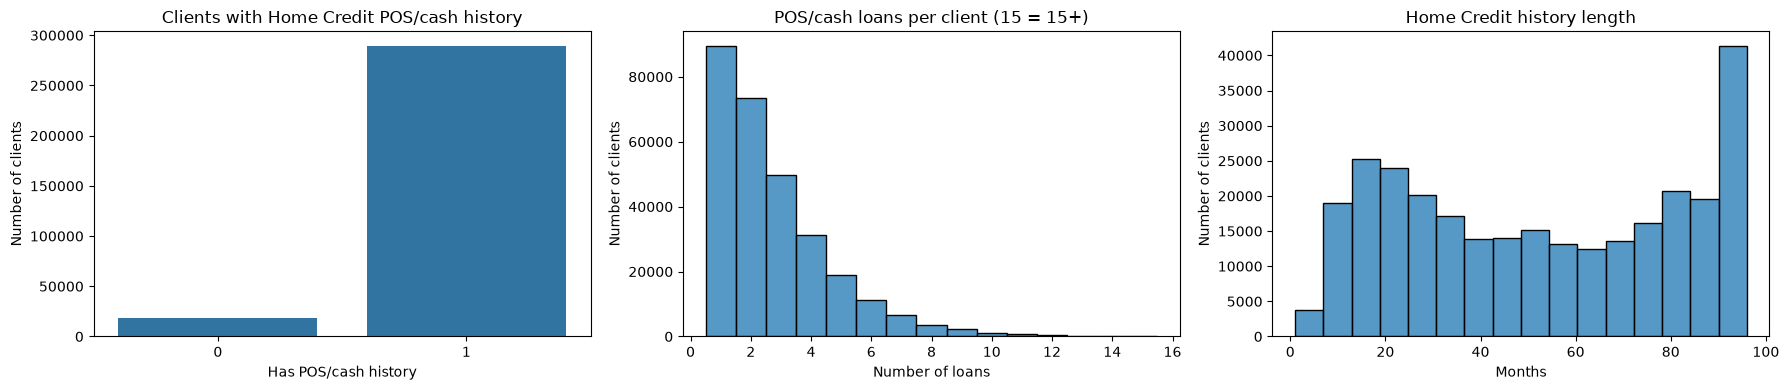

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df_train, x='HAS_POS', ax=axes[0])
axes[0].set_title('Clients with Home Credit POS/cash history')
axes[0].set_xlabel('Has POS/cash history')
axes[0].set_ylabel('Number of clients')

sns.histplot(x=df_train['POS_N_LOANS'].clip(upper=15), discrete=True, ax=axes[1])
axes[1].set_title('POS/cash loans per client (15 = 15+)')
axes[1].set_xlabel('Number of loans')
axes[1].set_ylabel('Number of clients')

sns.histplot(x=df_train['POS_HIST_LEN'], binwidth=6, ax=axes[2])
axes[2].set_title('Home Credit history length')
axes[2].set_xlabel('Months')
axes[2].set_ylabel('Number of clients')

plt.tight_layout()
plt.show()

### POS/cash hypotheses
Default rate across bins of each POS/cash feature. Error bars show the standard error.

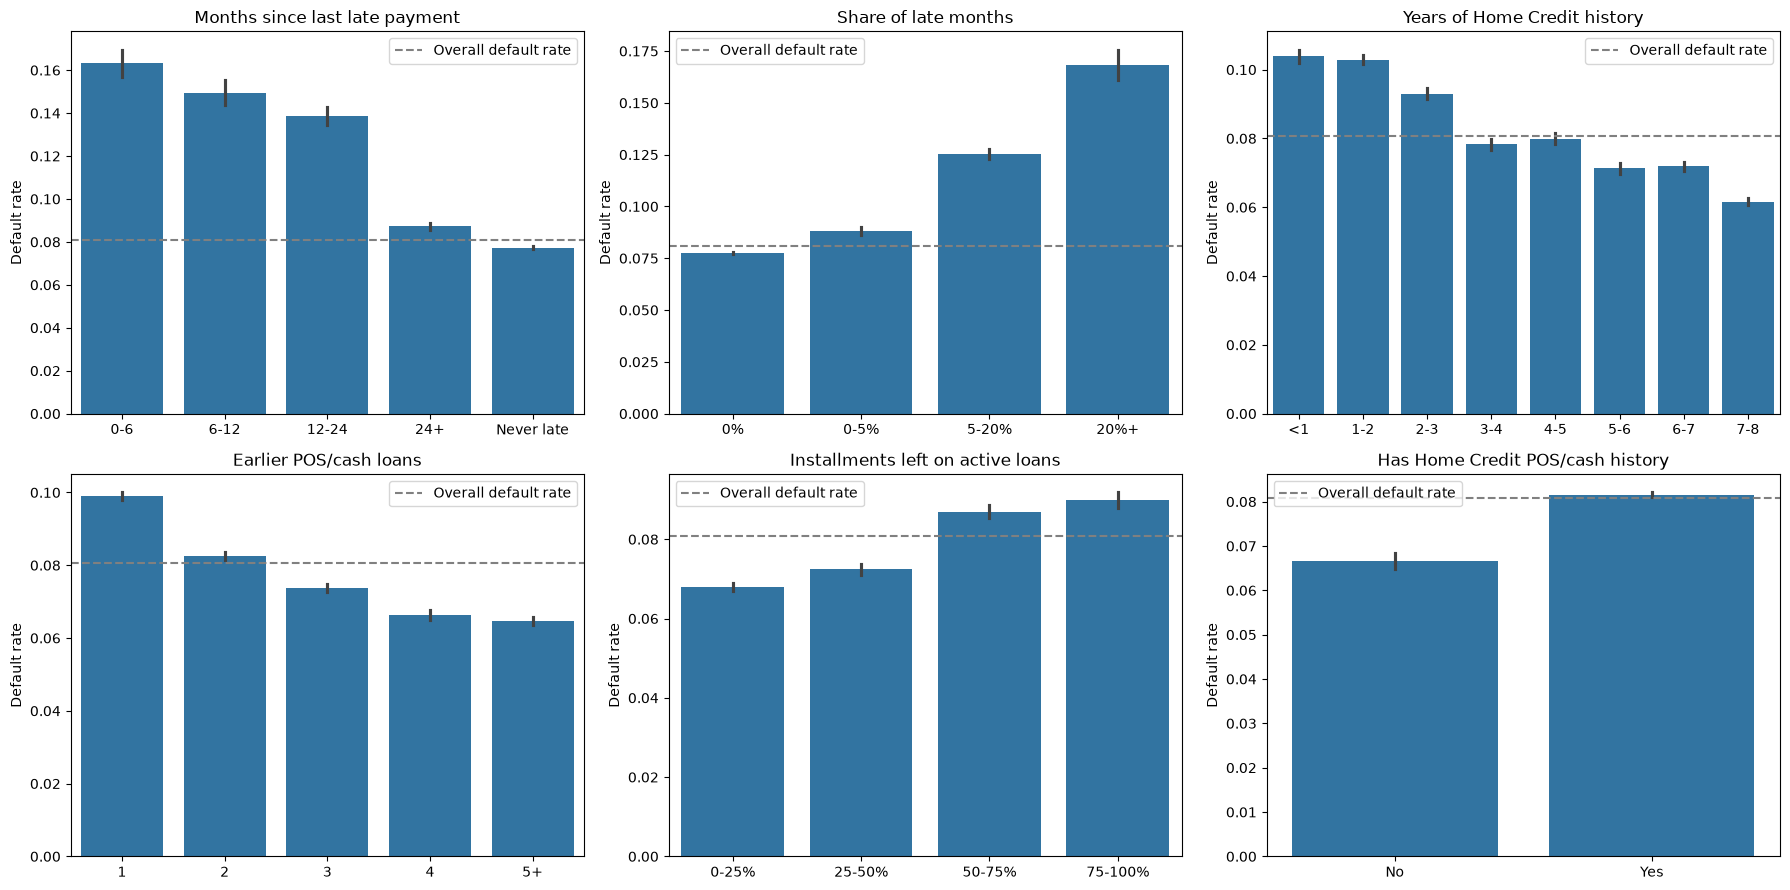

In [94]:
# Clients without POS history get 999 months since DPD, so keep only clients with history.
with_pos = df_train['HAS_POS'].eq(1)
binned = {
    'Months since last late payment': pd.cut(
        df_train['POS_MONTHS_SINCE_DPD'].where(with_pos), [0, 6, 12, 24, 998, np.inf],
        labels=['0-6', '6-12', '12-24', '24+', 'Never late'], include_lowest=True),
    'Share of late months': pd.cut(
        df_train['POS_DPD_SHARE'], [-0.001, 0, 0.05, 0.2, 1],
        labels=['0%', '0-5%', '5-20%', '20%+']),
    'Years of Home Credit history': pd.cut(
        df_train['POS_HIST_LEN'] / 12, range(9),
        labels=['<1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8'], include_lowest=True),
    'Earlier POS/cash loans': pd.cut(
        df_train['POS_N_LOANS'], [0.5, 1.5, 2.5, 3.5, 4.5, np.inf],
        labels=['1', '2', '3', '4', '5+']),
    'Installments left on active loans': pd.cut(
        df_train['POS_PROGRESS_LEFT'].clip(upper=1), [0, 0.25, 0.5, 0.75, 1],
        labels=['0-25%', '25-50%', '50-75%', '75-100%'], include_lowest=True),
    'Has Home Credit POS/cash history': pd.Categorical(df_train['HAS_POS'].map({0: 'No', 1: 'Yes'}), categories=['No', 'Yes']),
}
overall_rate = df_train['TARGET'].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (title, values) in zip(axes.flat, binned.items()):
    sns.barplot(x=values, y=df_train['TARGET'], errorbar='se', ax=ax)
    ax.axhline(overall_rate, color='grey', linestyle='--', label='Overall default rate')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Default rate')
    ax.legend()
plt.tight_layout()
plt.show()

## XGBoost model
Train XGBoost on application, credit bureau, and Home Credit POS/cash features with stratified 5-fold cross-validation.

In [83]:
contact_flags = [
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
]

document_flags = [f'FLAG_DOCUMENT_{number}' for number in range(2, 22)]
rating_columns = ['REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT']
social_observed = [f'OBS_{days}_CNT_SOCIAL_CIRCLE' for days in (30, 60)]
social_defaulted = [f'DEF_{days}_CNT_SOCIAL_CIRCLE' for days in (30, 60)]
social_columns = social_observed + social_defaulted

numeric_raw = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
]
categorical = [
    'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'ORGANIZATION_TYPE',
]
feature_columns = numeric_raw + contact_flags + document_flags + rating_columns + social_columns + bureau_features + pos_features + categorical
X = df_train[feature_columns]
X_kaggle_test = df_test[feature_columns]
y = df_train['TARGET']

X_train_val, y_train_val = X, y
X_kaggle_test = X_kaggle_test[X_train_val.columns]
assert X_kaggle_test.columns.equals(X_train_val.columns)
print(f'All datasets have the same {len(feature_columns)} input columns.')
print(f'train + validation (5-fold CV): {len(y_train_val):,} rows, target rate {y_train_val.mean():.2%}')

All datasets have the same 70 input columns.
train + validation (5-fold CV): 307,511 rows, target rate 8.07%


In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline

def make_features(frame):
    frame = frame.copy()
    frame['CONTACT_FLAG_SCORE'] = frame[contact_flags].sum(axis=1) / len(contact_flags)
    frame['DOCUMENT_FLAG_SCORE'] = frame[document_flags].sum(axis=1) / len(document_flags)
    city = frame['REGION_RATING_CLIENT_W_CITY'].replace(-1, np.nan)
    region = frame['REGION_RATING_CLIENT'].replace(-1, np.nan)
    frame['REGION_RATING_SCORE'] = (0.7 * city + 0.3 * region).fillna(city).fillna(region)
    for days in (30, 60):
        observed = frame[f'OBS_{days}_CNT_SOCIAL_CIRCLE']
        defaulted = frame[f'DEF_{days}_CNT_SOCIAL_CIRCLE']
        frame[f'SOCIAL_DEFAULT_RATE_{days}'] = defaulted.div(observed).where(observed.ne(0), 0)
    frame['AGE_YEARS'] = -frame['DAYS_BIRTH'] / 365.25
    frame['AGE_BIN'] = pd.cut(frame['AGE_YEARS'], bins=np.linspace(20, 70, num=11), labels=False, include_lowest=True)
    frame['DAYS_EMPLOYED_ANOM'] = frame['DAYS_EMPLOYED'].eq(365243).astype(int)
    frame['EMPLOYED_YEARS'] = -frame['DAYS_EMPLOYED'].replace(365243, np.nan) / 365.25
    frame['YEARS_SINCE_REGISTRATION'] = -frame['DAYS_REGISTRATION'] / 365.25
    frame['YEARS_SINCE_ID_PUBLISH'] = -frame['DAYS_ID_PUBLISH'] / 365.25
    frame['YEARS_SINCE_PHONE_CHANGE'] = -frame['DAYS_LAST_PHONE_CHANGE'] / 365.25
    return frame.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'] + contact_flags + document_flags + rating_columns + social_defaulted)

print(f"Employment anomalies in competition test: {X_kaggle_test['DAYS_EMPLOYED'].eq(365243).sum():,} / {len(X_kaggle_test):,}")

numeric = [column for column in numeric_raw if not column.startswith('DAYS_') and column != 'OWN_CAR_AGE'] + [
    'AGE_YEARS', 'AGE_BIN', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED_ANOM',
    'YEARS_SINCE_REGISTRATION', 'YEARS_SINCE_ID_PUBLISH', 'YEARS_SINCE_PHONE_CHANGE',
    'CONTACT_FLAG_SCORE',
    'DOCUMENT_FLAG_SCORE',
    'REGION_RATING_SCORE',
    *social_observed, 'SOCIAL_DEFAULT_RATE_30', 'SOCIAL_DEFAULT_RATE_60',
]
preprocess = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric),
        ('car_age', SimpleImputer(strategy='median', add_indicator=True), ['OWN_CAR_AGE']),
        ('bureau', SimpleImputer(strategy='constant', fill_value=0), bureau_features),
        ('pos', SimpleImputer(strategy='constant', fill_value=0), pos_features),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
    ],
    sparse_threshold=1.0,
)


Employment anomalies in competition test: 9,274 / 48,744


In [85]:
from sklearn.base import clone
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=3000, early_stopping_rounds=100,
    max_depth=4, learning_rate=0.03,
    min_child_weight=50, reg_lambda=5, gamma=1,
    subsample=0.8, colsample_bytree=0.5,
    tree_method='hist', eval_metric='auc', importance_type='gain',
    n_jobs=4, random_state=SEED,
)
model = Pipeline([
    ('features', FunctionTransformer(make_features)),
    ('preprocess', clone(preprocess)),
    ('model', xgb),
])

def best_f1_threshold(labels, scores):
    precision, recall, thresholds = precision_recall_curve(labels, scores)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return thresholds[np.argmax(f1)]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_models, fold_indices, fold_rows = [], [], []
oof_scores = np.zeros(len(X_train_val))
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_val, y_train_val), start=1):
    X_tr, X_va = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_tr, y_va = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    fold_model = clone(model)
    # Fit preprocessing first so the validation fold can be transformed for early stopping.
    fold_model[:-1].fit(X_tr, y_tr)
    fold_model[-1].fit(fold_model[:-1].transform(X_tr), y_tr,
                       eval_set=[(fold_model[:-1].transform(X_va), y_va)], verbose=False)
    train_scores = fold_model.predict_proba(X_tr)[:, 1]
    val_scores = fold_model.predict_proba(X_va)[:, 1]
    oof_scores[val_idx] = val_scores
    threshold = best_f1_threshold(y_va, val_scores)
    fold_rows.append({
        'fold': fold,
        'trees': fold_model[-1].best_iteration + 1,
        'train_auc': roc_auc_score(y_tr, train_scores),
        'val_auc': roc_auc_score(y_va, val_scores),
        'train_pr_auc': average_precision_score(y_tr, train_scores),
        'val_pr_auc': average_precision_score(y_va, val_scores),
        'threshold': threshold,
        'train_f1': f1_score(y_tr, train_scores >= threshold),
        'val_f1': f1_score(y_va, val_scores >= threshold),
    })
    print(f"Fold {fold}: trees={fold_rows[-1]['trees']}, "
          f"train AUC={fold_rows[-1]['train_auc']:.4f}, val AUC={fold_rows[-1]['val_auc']:.4f}, "
          f"val PR-AUC={fold_rows[-1]['val_pr_auc']:.4f}, "
          f"threshold={threshold:.3f}, val F1={fold_rows[-1]['val_f1']:.4f}")
    fold_models.append(fold_model)
    fold_indices.append((train_idx, val_idx))

processed_columns = fold_models[0].named_steps['preprocess'].get_feature_names_out()
assert fold_models[0][:-1].transform(X_kaggle_test.head()).shape[1] == len(processed_columns)
print(f'All datasets have the same {len(processed_columns)} processed features.')

# One threshold from all out-of-fold predictions is more stable than averaging per-fold thresholds.
decision_threshold = best_f1_threshold(y_train_val, oof_scores)
print(f'OOF ROC AUC: {roc_auc_score(y_train_val, oof_scores):.4f}')
# PR-AUC baseline for a random model is the positive rate, not 0.5.
print(f'OOF PR-AUC: {average_precision_score(y_train_val, oof_scores):.4f} '
      f'(baseline {y_train_val.mean():.4f})')
print(f'OOF decision threshold: {decision_threshold:.3f}')

fold_table = pd.DataFrame(fold_rows).set_index('fold')
pd.concat([fold_table, fold_table.agg(['mean', 'std'])]).round(4)

Fold 1: trees=1387, train AUC=0.8016, val AUC=0.7678, val PR-AUC=0.2604, threshold=0.148, val F1=0.3218
Fold 2: trees=1649, train AUC=0.8049, val AUC=0.7755, val PR-AUC=0.2680, threshold=0.165, val F1=0.3299
Fold 3: trees=1977, train AUC=0.8123, val AUC=0.7677, val PR-AUC=0.2518, threshold=0.165, val F1=0.3146
Fold 4: trees=1904, train AUC=0.8093, val AUC=0.7753, val PR-AUC=0.2668, threshold=0.152, val F1=0.3296
Fold 5: trees=1860, train AUC=0.8099, val AUC=0.7668, val PR-AUC=0.2535, threshold=0.150, val F1=0.3139
All datasets have the same 123 processed features.
OOF ROC AUC: 0.7706
OOF PR-AUC: 0.2598 (baseline 0.0807)
OOF decision threshold: 0.151


,trees,train_auc,val_auc,train_pr_auc,val_pr_auc,threshold,train_f1,val_f1
1,1387.0000,0.8016,0.7678,0.3111,0.2604,0.1482,0.3541,0.3218
2,1649.0000,0.8049,0.7755,0.3169,0.2680,0.1645,0.3612,0.3299
3,1977.0000,0.8123,0.7677,0.3312,0.2518,0.1649,0.3701,0.3146
4,1904.0000,0.8093,0.7753,0.3250,0.2668,0.1520,0.3635,0.3296
5,1860.0000,0.8099,0.7668,0.3277,0.2535,0.1497,0.3658,0.3139
mean,1755.4000,0.8076,0.7706,0.3224,0.2601,0.1559,0.3629,0.3220
std,239.3581,0.0043,0.0044,0.0082,0.0074,0.0082,0.0060,0.0077


### Feature importance
XGBoost gain importance, averaged over the five fold models.

In [86]:
importance = pd.concat([
    pd.Series(fold_model[-1].feature_importances_,
              index=fold_model.named_steps['preprocess'].get_feature_names_out())
    for fold_model in fold_models
], axis=1).mean(axis=1)
importance_table = (
    importance.rename('gain_importance').rename_axis('feature')
    .sort_values(ascending=False).reset_index()
)
importance_table.insert(0, 'rank', range(1, len(importance_table) + 1))
importance_table['top_15'] = importance_table['rank'] <= 15
importance_table

,rank,feature,gain_importance,top_15
0,1,numeric__EXT_SOURCE_2,0.074125,True
1,2,bureau__HAS_BUREAU,0.069508,True
2,3,numeric__EXT_SOURCE_3,0.066986,True
3,4,categorical__NAME_EDUCATION_TYPE_Higher education,0.047645,True
4,5,categorical__NAME_INCOME_TYPE_Working,0.032684,True
...,...,...,...,...
118,119,categorical__ORGANIZATION_TYPE_Trade: type 1,0.000000,False
119,120,categorical__ORGANIZATION_TYPE_Trade: type 5,0.000000,False
120,121,categorical__ORGANIZATION_TYPE_Trade: type 6,0.000000,False
121,122,categorical__ORGANIZATION_TYPE_Transport: type 1,0.000000,False


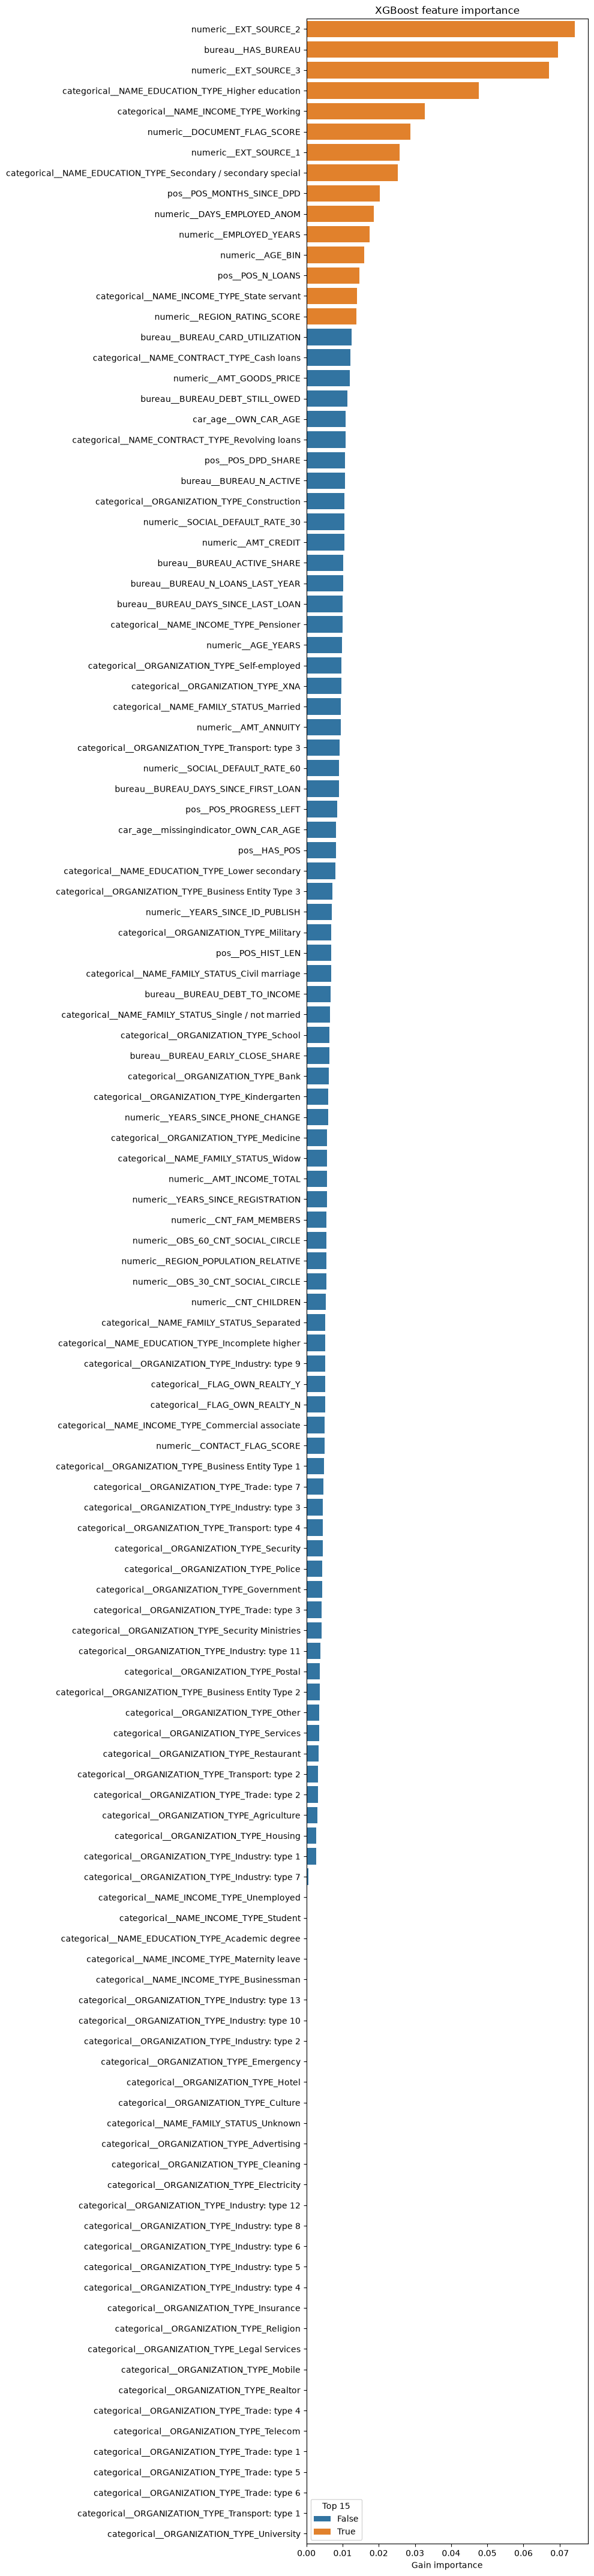

In [87]:
fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(importance_table))))
sns.barplot(
    data=importance_table, x='gain_importance', y='feature',
    hue='top_15', dodge=False, ax=ax,
)
ax.set_title('XGBoost feature importance')
ax.set_xlabel('Gain importance')
ax.set_ylabel('')
ax.legend(title='Top 15')
plt.tight_layout()
plt.show()


### Training curves
Track log loss, F1, and ROC AUC on the train and validation parts of fold 1. Both F1 curves use the out-of-fold decision threshold.

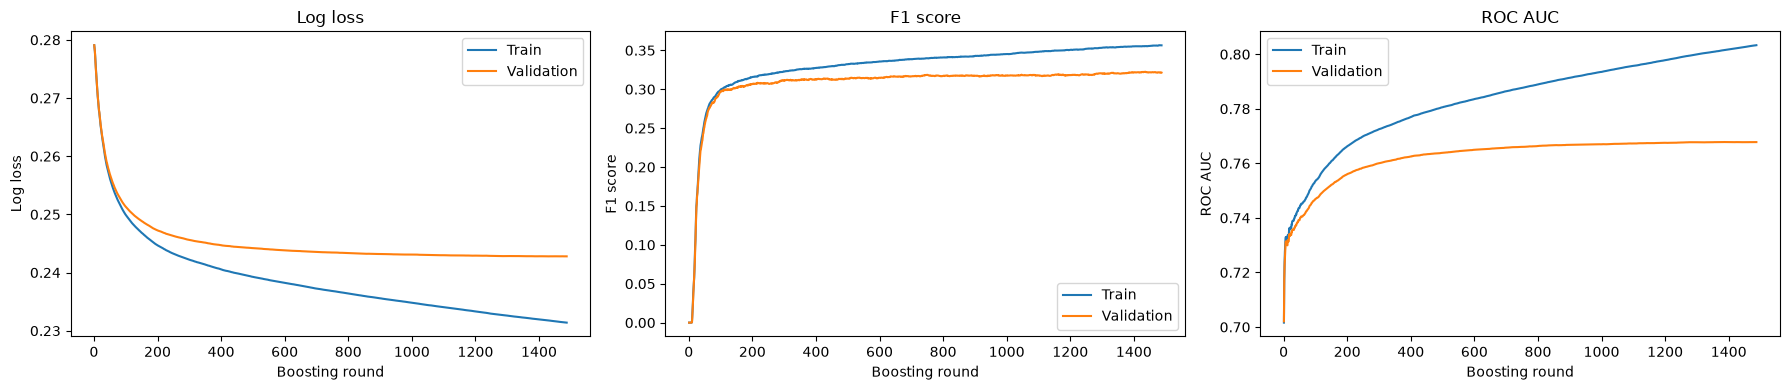

In [88]:
from xgboost import DMatrix, train as train_xgb

curve_model = fold_models[0]
train_idx, val_idx = fold_indices[0]
train_matrix = DMatrix(curve_model[:-1].transform(X_train_val.iloc[train_idx]), label=y_train_val.iloc[train_idx])
val_matrix = DMatrix(curve_model[:-1].transform(X_train_val.iloc[val_idx]), label=y_train_val.iloc[val_idx])

def f1_metric(y_pred, data):
    return 'f1', f1_score(data.get_label(), y_pred >= decision_threshold, zero_division=0)

params = {key: value for key, value in xgb.get_xgb_params().items() if value is not None}
params['eval_metric'] = ['logloss', 'auc']
history = {}
train_xgb(
    params, train_matrix, num_boost_round=curve_model[-1].get_booster().num_boosted_rounds(),
    evals=[(train_matrix, 'train'), (val_matrix, 'validation')],
    custom_metric=f1_metric, evals_result=history, verbose_eval=False,
)
rounds = range(1, len(history['train']['logloss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric, title in zip(axes, ['logloss', 'f1', 'auc'], ['Log loss', 'F1 score', 'ROC AUC']):
    sns.lineplot(x=rounds, y=history['train'][metric], ax=ax, label='Train')
    sns.lineplot(x=rounds, y=history['validation'][metric], ax=ax, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Boosting round')
    ax.set_ylabel(title)
plt.tight_layout()
plt.show()

### Out-of-fold scores
Each train-plus-validation row gets one prediction from the fold model that did not train on it. The decision threshold maximizes F1 on these out-of-fold predictions, so OOF F1 is slightly optimistic.

OOF decision threshold: 0.151 (mean of per-fold thresholds: 0.156)
              precision    recall  f1-score   support

           0       0.95      0.89      0.92    282686
           1       0.25      0.44      0.32     24825

    accuracy                           0.85    307511
   macro avg       0.60      0.66      0.62    307511
weighted avg       0.89      0.85      0.87    307511



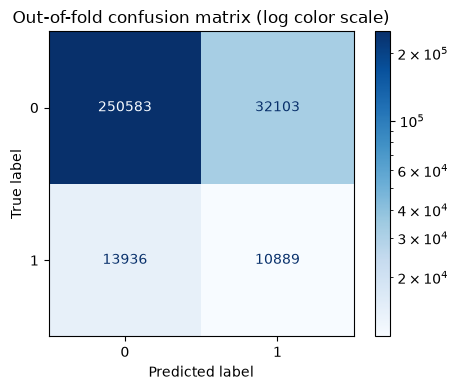

In [89]:
from matplotlib.colors import LogNorm
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

oof_predictions = (oof_scores >= decision_threshold).astype(int)
print(f"OOF decision threshold: {decision_threshold:.3f} "
      f"(mean of per-fold thresholds: {fold_table['threshold'].mean():.3f})")
print(classification_report(y_train_val, oof_predictions, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train_val, oof_predictions, display_labels=[0, 1],
    cmap='Blues', values_format='d', ax=ax,
    im_kw={'norm': LogNorm()},
)
ax.set_title('Out-of-fold confusion matrix (log color scale)')
plt.tight_layout()
plt.show()

### ROC curve
Out-of-fold predictions stand in for validation: each training row is scored by the fold model that did not see it.


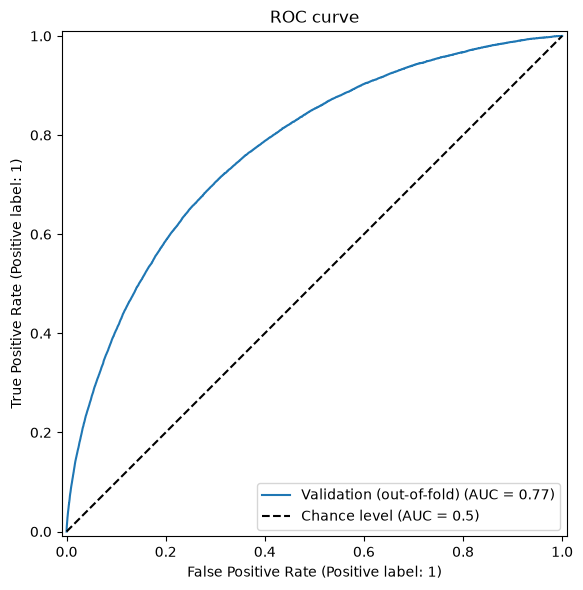

In [90]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_train_val, oof_scores, name='Validation (out-of-fold)', ax=ax, plot_chance_level=True)
ax.set_title('ROC curve')
plt.tight_layout()
plt.show()


### Kaggle submission

In [91]:
sample_submission = pd.read_csv(DATA_PATH / 'sample_submission.csv')
kaggle_scores = np.mean([fold_model.predict_proba(X_kaggle_test)[:, 1] for fold_model in fold_models], axis=0)
submission = pd.DataFrame({'SK_ID_CURR': df_test['SK_ID_CURR'], 'TARGET': kaggle_scores})
assert set(submission['SK_ID_CURR']) == set(sample_submission['SK_ID_CURR'])
submission.to_csv('submission.csv', index=False)
print(f'Saved submission.csv: {len(submission):,} rows, mean predicted default {kaggle_scores.mean():.4f}')
submission.head()

Saved submission.csv: 48,744 rows, mean predicted default 0.0788


,SK_ID_CURR,TARGET
0,100001,0.032305
1,100005,0.133682
2,100013,0.025723
3,100028,0.030862
4,100038,0.155119
